# Gridded ABM Hyetograph Generation

This notebook demonstrates how to generate spatially distributed precipitation hyetographs
using the Alternating Block Method (ABM) applied pixel-by-pixel across a NOAA Atlas 14 grid.
The output is a NetCDF file with dimensions `(time, lat, lon)` ready for direct import into
HEC-RAS as a rain-on-grid 2D precipitation boundary condition.

**Key Features:**
- Per-pixel temporal distribution using the ABM (Chow, Maidment, Mays 1988)
- Spatial depth data from NOAA Atlas 14 CONUS NetCDF via HTTP byte-range requests
- Sub-hourly intervals via centroid DDF ratios (no separate download required)
- Fully vectorized across all grid pixels — large domains run in seconds
- CF-1.8 compliant NetCDF output with `precip_incremental` and `precip_cumulative` variables

**Example 1 — Direct Bounds:** Generate a 100-year 24-hour ABM grid for a user-specified bounding box (Houston, TX area)

**Example 2 — HEC-RAS Project Bounds:** Derive the bounding box automatically from a HEC-RAS geometry HDF file

**Alternative Workflow:** Use `generate_from_asc_files()` with pre-downloaded NOAA Atlas 14 .asc grids

In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
USE_LOCAL_SOURCE = False  # <-- TOGGLE THIS

if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path
    local_path = str(Path.cwd().parent)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print(f"LOCAL SOURCE MODE: Loading from {local_path}/ras_commander")
else:
    print("PIP PACKAGE MODE: Loading installed ras-commander")

import ras_commander
print(f"Loaded: {ras_commander.__file__}")

PIP PACKAGE MODE: Loading installed ras-commander


Loaded: <workspace>\ras_commander\__init__.py


## Example 1 — Direct Bounds (Houston, TX)

The simplest workflow: provide a bounding box in decimal degrees and let `AbmHyetographGrid.generate()`
handle everything — Atlas 14 download, sub-hourly gap filling, ABM temporal distribution, and
NetCDF export.

**Configuration:**
- **Location:** Houston, TX area
- **Return period:** 100-year (ARI = 100)
- **Storm duration:** 24 hours
- **Timestep:** 15 minutes (96 intervals)
- **Peak position:** 50% (centered)

In [2]:
from pathlib import Path
from ras_commander.precip import AbmHyetographGrid

# --- Configuration ---
BOUNDS = (-95.5, 29.5, -95.0, 30.0)   # (west, south, east, north) decimal degrees WGS84
ARI_YEARS = 100                         # 100-year return period
STORM_DURATION_HR = 24.0               # 24-hour storm
TIMESTEP_MIN = 15                       # 15-minute intervals
PEAK_POSITION_PCT = 50.0               # peak at midpoint of storm
OUTPUT_NC = Path("abm_houston_100yr_24hr.nc")

# --- Generate ---
nc_path = AbmHyetographGrid.generate(
    bounds=BOUNDS,
    ari_years=ARI_YEARS,
    storm_duration_hours=STORM_DURATION_HR,
    timestep_minutes=TIMESTEP_MIN,
    peak_position_percent=PEAK_POSITION_PCT,
    output_netcdf=OUTPUT_NC,
)

print(f"Output: {nc_path}")
print(f"File size: {nc_path.stat().st_size / 1024:.1f} KB")

2026-06-12 14:33:57 - ras_commander.precip.AbmHyetographGrid - INFO - Generating ABM grid: ARI=100yr, duration=24.0hr, dt=15min, peak@50.0%, bounds=(-95.5, 29.5, -95.0, 30.0)


2026-06-12 14:33:57 - ras_commander.precip.AbmHyetographGrid - INFO - Downloading Atlas 14 data for 7 hourly durations...


2026-06-12 14:33:57 - ras_commander.precip.Atlas14Grid - INFO - Loading Atlas 14 coordinate arrays from remote file...


2026-06-12 14:35:36 - ras_commander.precip.Atlas14Grid - INFO - Loaded coordinates: lat=3121, lon=7081, ari=9


2026-06-12 14:35:36 - ras_commander.precip.Atlas14Grid - INFO - Extracting Atlas 14 data for bounds (-95.5250, 29.4750, -94.9750, 30.0250): lat[658:724], lon[3538:3604]


...

2026-06-12 14:38:53 - ras_commander.precip.StormGenerator - INFO - Downloaded Atlas 14 data for region: Texas


2026-06-12 14:38:53 - ras_commander.precip.AbmHyetographGrid - INFO - Computing ABM temporal distribution across grid (96 intervals)...


2026-06-12 14:38:53 - ras_commander.precip.AbmHyetographGrid - INFO - Wrote NetCDF: <workspace>\examples\abm_houston_100yr_24hr.nc (96 timesteps × 66 lat × 66 lon)


2026-06-12 14:38:53 - ras_commander.precip.AbmHyetographGrid - INFO - ABM grid complete → <workspace>\examples\abm_houston_100yr_24hr.nc


Output: <workspace>\examples\abm_houston_100yr_24hr.nc
File size: 1567.2 KB


## 1. Inspect the NetCDF Output

Open the NetCDF with xarray to examine dimensions, coordinates, and variables.

In [3]:
import xarray as xr
import numpy as np

ds = xr.open_dataset(nc_path, decode_timedelta=False)
print(ds)
print()
print("Attributes:")
for k, v in ds.attrs.items():
    print(f"  {k}: {v}")

<xarray.Dataset> Size: 3MB
Dimensions:             (time: 96, lat: 66, lon: 66)
Coordinates:
  * time                (time) float64 768B 0.0 0.25 0.5 ... 23.25 23.5 23.75
  * lat                 (lat) float64 528B 29.48 29.49 29.5 ... 30.02 30.02
  * lon                 (lon) float64 528B -95.52 -95.51 -95.5 ... -94.98 -94.98
Data variables:
    precip_incremental  (time, lat, lon) float32 2MB ...
    precip_cumulative   (time, lat, lon) float32 2MB ...
Attributes:
    Conventions:  CF-1.8
    title:        ABM Hyetograph Grid - 100-yr 24-hr Storm
    institution:  Generated by ras-commander AbmHyetographGrid
    source:       NOAA Atlas 14 CONUS NetCDF + centroid DDF ratios (AbmHyetog...
    history:      Created 2026-06-12 18:38:53 UTC
    comment:      Alternating Block Method temporal distribution. ARI=100yr, ...
    references:   Chow, V.T., Maidment, D.R., Mays, L.W. (1988). Applied Hydr...

Attributes:
  Conventions: CF-1.8
  title: ABM Hyetograph Grid - 100-yr 24-hr Storm
  ins

In [4]:
# Basic statistics on the incremental depth field
incr = ds['precip_incremental'].values  # shape: (time, lat, lon)
n_time, n_lat, n_lon = incr.shape

print(f"Grid dimensions: {n_lat} lat x {n_lon} lon")
print(f"Time steps: {n_time} ({TIMESTEP_MIN}-min intervals = {n_time * TIMESTEP_MIN / 60:.1f} hr)")
print(f"Lat range: {ds.lat.values.min():.4f} to {ds.lat.values.max():.4f} deg N")
print(f"Lon range: {ds.lon.values.min():.4f} to {ds.lon.values.max():.4f} deg E")
print()

# Per-pixel storm total (cumulative at last timestep)
cumul = ds['precip_cumulative'].values  # shape: (time, lat, lon)
totals = cumul[-1, :, :]               # last timestep = storm total

print(f"Storm total depth across grid:")
print(f"  Min : {np.nanmin(totals):.3f} inches")
print(f"  Max : {np.nanmax(totals):.3f} inches")
print(f"  Mean: {np.nanmean(totals):.3f} inches")
print(f"  Range: {np.nanmax(totals) - np.nanmin(totals):.3f} inches  "
      f"({(np.nanmax(totals) - np.nanmin(totals)) / np.nanmin(totals) * 100:.1f}%)")

ds.close()

Grid dimensions: 66 lat x 66 lon
Time steps: 96 (15-min intervals = 24.0 hr)
Lat range: 29.4833 to 30.0250 deg N
Lon range: -95.5167 to -94.9750 deg E



Storm total depth across grid:
  Min : 16.320 inches
  Max : 18.230 inches
  Mean: 17.447 inches
  Range: 1.910 inches  (11.7%)


## 2. Visualize the Grid

Two views:
1. **Spatial map** — storm total depth across the domain (reflects Atlas 14 spatial gradient)
2. **Sample pixel hyetograph** — incremental depth time series at the domain centroid

Centroid pixel total: 17.440 inches
Peak interval: 2.6323 inches at t=11.75 hr (49.0% of storm)


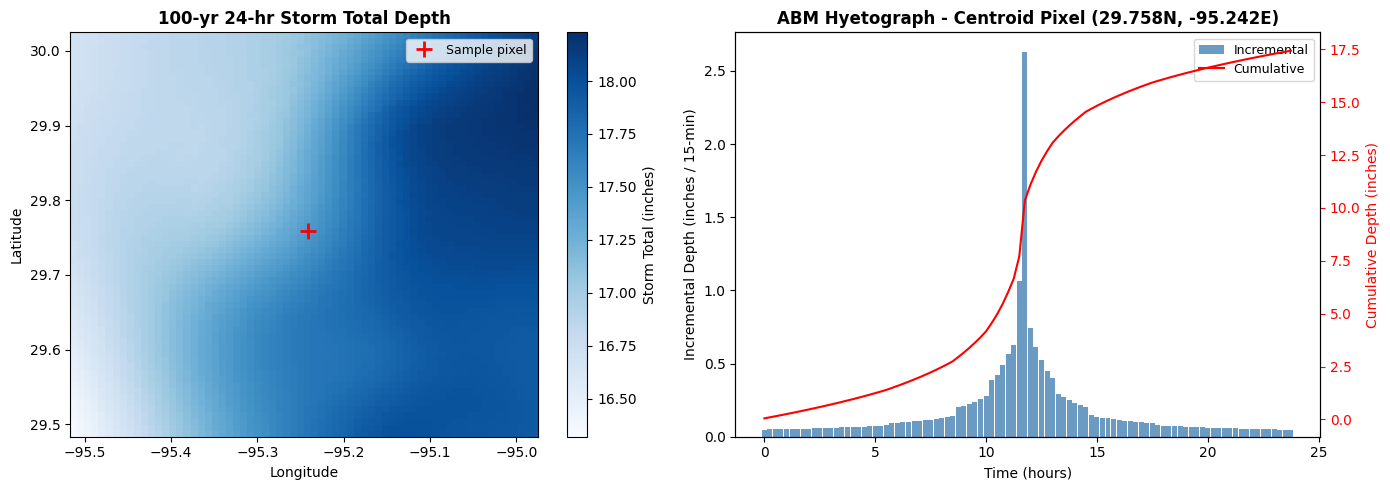

In [5]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

ds = xr.open_dataset(nc_path, decode_timedelta=False)
lats = ds.lat.values
lons = ds.lon.values
cumul = ds['precip_cumulative'].values
incr  = ds['precip_incremental'].values

totals = cumul[-1, :, :]  # storm total at each pixel

# --- Plot 1: Spatial storm total ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
im = ax.imshow(
    totals,
    origin='lower',
    extent=[lons.min(), lons.max(), lats.min(), lats.max()],
    cmap='Blues',
    aspect='auto',
)
plt.colorbar(im, ax=ax, label='Storm Total (inches)')
ax.set_title(f'{ARI_YEARS}-yr {STORM_DURATION_HR:.0f}-hr Storm Total Depth', fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Mark centroid
clat = lats[len(lats) // 2]
clon = lons[len(lons) // 2]
ax.plot(clon, clat, 'r+', markersize=12, markeredgewidth=2, label='Sample pixel')
ax.legend(fontsize=9)

# --- Plot 2: Sample pixel hyetograph ---
lat_idx = len(lats) // 2
lon_idx = len(lons) // 2
pixel_incr  = incr[:, lat_idx, lon_idx]
pixel_cumul = cumul[:, lat_idx, lon_idx]
time_hr = np.arange(len(pixel_incr)) * TIMESTEP_MIN / 60.0

ax2 = axes[1]
ax2.bar(time_hr, pixel_incr, width=TIMESTEP_MIN / 60.0 * 0.9,
        color='steelblue', alpha=0.8, label='Incremental')
ax2b = ax2.twinx()
ax2b.plot(time_hr, pixel_cumul, 'r-', linewidth=1.5, label='Cumulative')
ax2b.set_ylabel('Cumulative Depth (inches)', color='r')
ax2b.tick_params(axis='y', colors='r')

ax2.set_xlabel('Time (hours)')
ax2.set_ylabel('Incremental Depth (inches / 15-min)')
ax2.set_title(f'ABM Hyetograph - Centroid Pixel ({clat:.3f}N, {clon:.3f}E)', fontweight='bold')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

print(f"Centroid pixel total: {pixel_cumul[-1]:.3f} inches")
print(f"Peak interval: {pixel_incr.max():.4f} inches at t={time_hr[pixel_incr.argmax()]:.2f} hr "
      f"({pixel_incr.argmax() / len(pixel_incr) * 100:.1f}% of storm)")

plt.tight_layout()
plt.show()
ds.close()

## 3. QC Verification with verify_pixel()

Compare a pixel's storm total against the NOAA PFDS point DDF value at the same location.
This confirms that depth conservation is maintained through the ABM process.

In [6]:
# QC: verify depth conservation for a pixel (internal consistency check)
# Compares sum(incremental) vs cumulative[-1] from the same NetCDF —
# no external data source needed; validates ABM rearrangement + float32 encoding.

check_lat = (BOUNDS[1] + BOUNDS[3]) / 2.0
check_lon = (BOUNDS[0] + BOUNDS[2]) / 2.0

qc = AbmHyetographGrid.verify_pixel(
    netcdf_path=nc_path,
    lat=check_lat,
    lon=check_lon,
    tolerance_pct=0.1,
)

print("QC Result (internal consistency):")
print(f"  Pixel grid location: ({qc['lat_actual']:.4f}N, {qc['lon_actual']:.4f}E)")
print(f"  Pixel storm total:   {qc['pixel_total_in']:.4f} inches  (sum of incremental)")
print(f"  NetCDF reference:    {qc['reference_depth_in']:.4f} inches  (cumulative[-1])")
print(f"  Error:               {qc['error_pct']:.4f}%")
print(f"  Status: {'PASS' if qc['passed'] else 'FAIL'} (tolerance: 0.1%)")

2026-06-12 14:38:54 - ras_commander.precip.AbmHyetographGrid - INFO - QC PASS: pixel (29.7500N, -95.2500E) total=17.4200in, ref=17.4200in, error=0.0000%


QC Result (internal consistency):
  Pixel grid location: (29.7500N, -95.2500E)
  Pixel storm total:   17.4200 inches  (sum of incremental)
  NetCDF reference:    17.4200 inches  (cumulative[-1])
  Error:               0.0000%
  Status: PASS (tolerance: 0.1%)


## Example 2 — HEC-RAS Project Bounds (Bald Eagle Creek)

For an existing HEC-RAS rain-on-grid model, derive the bounding box directly from the
2D flow area in the geometry HDF file.  This ensures the ABM grid exactly covers
the model domain without manually specifying coordinates.

**Workflow:**
1. Extract a HEC-RAS example project with a 2D flow area
2. Read the 2D area extent from the geometry HDF
3. Generate an ABM grid clipped to that extent

In [7]:
from ras_commander import RasExamples, init_ras_project
from ras_commander.precip import Atlas14Grid

# Extract example project
project_path = RasExamples.extract_project("BaldEagleCrkMulti2D", suffix="abm_grid")
print(f"Project: {project_path}")

ras = init_ras_project(project_path, ras_version="6.6")

# Find geometry HDF
geom_hdfs = sorted(project_path.glob("*.g*.hdf"))
geom_hdf = geom_hdfs[0]
print(f"Geometry HDF: {geom_hdf.name}")

2026-06-12 14:38:55 - ras_commander.RasExamples - INFO - Successfully extracted project 'BaldEagleCrkMulti2D' to <workspace>\examples\example_projects\BaldEagleCrkMulti2D_abm_grid


2026-06-12 14:38:55 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at <hec-ras-install>\7.0\Ras.exe via filesystem (x86)


2026-06-12 14:38:55 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at <hec-ras-install>\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-06-12 14:38:55 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.6 at <hec-ras-install>\6.6\Ras.exe via filesystem (x86)


2026-06-12 14:38:55 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at <hec-ras-install>\6.5\Ras.exe via filesystem (x86)


...

2026-06-12 14:38:55 - ras_commander.RasPrj - INFO - ras-commander v0.98.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://rascommander.info | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-06-12 14:38:55 - ras_commander.RasPrj - INFO - Project initialized: BaldEagleDamBrk | Folder: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_abm_grid


2026-06-12 14:38:55 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: <hec-ras-install>\6.6\Ras.exe


2026-06-12 14:38:55 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://rascommander.info/
Repo: https://github.com/gpt-cmdr/ras-commander
LLM agents: https://rascommander.info/llms.txt
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow associations
  ras.geom_df        Geometry files and HDF preprocessor paths
  ras.flow_df        Steady flow files
  ras.unsteady_df    Unsteady flow files and configurations
  ras.boundaries_df  Boundary conditions (type, name, location)
  ras.results_df     Lightweight HDF results summaries
  ras.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / compute_test_mode(

Geometry HDF: BaldEagleDamBrk.g01.hdf


In [8]:
# Read the 2D flow area extent from the geometry HDF
# Atlas14Grid.get_pfe_from_project() returns 'bounds' which we can reuse directly
pfe_meta = Atlas14Grid.get_pfe_from_project(
    geom_hdf=geom_hdf,
    extent_source="2d_flow_area",
    durations=[24],
    return_periods=[100],
    buffer_percent=5.0,
    ras_object=ras,
)

project_bounds = pfe_meta['bounds']  # (west, south, east, north)
print(f"2D flow area bounds (with 5% buffer):")
print(f"  West:  {project_bounds[0]:.4f}")
print(f"  South: {project_bounds[1]:.4f}")
print(f"  East:  {project_bounds[2]:.4f}")
print(f"  North: {project_bounds[3]:.4f}")
if 'mesh_area_names' in pfe_meta:
    print(f"  2D Areas: {pfe_meta['mesh_area_names']}")

2026-06-12 14:38:55 - ras_commander.precip.Atlas14Grid - INFO - Extracting extent from <workspace>\examples\example_projects\BaldEagleCrkMulti2D_abm_grid\BaldEagleDamBrk.g01.hdf using 2d_flow_area


2026-06-12 14:38:55 - ras_commander.precip.Atlas14Grid - INFO - 2D flow area bounds: W=-77.6324, S=41.0459, E=-77.3275, N=41.1842


2026-06-12 14:38:55 - ras_commander.precip.Atlas14Grid - INFO - Extracting Atlas 14 data for bounds (-77.6476, 41.0390, -77.3123, 41.1911): lat[2045:2063], lon[5683:5723]


2026-06-12 14:40:01 - ras_commander.precip.Atlas14Grid - INFO - Data transfer: 12.7 KB (vs 379.4 MB full grid, 100.0% reduction)


2D flow area bounds (with 5% buffer):
  West:  -77.6476
  South: 41.0390
  East:  -77.3123
  North: 41.1911
  2D Areas: ['BaldEagleCr']


In [9]:
# Generate ABM grid using the project bounds
OUTPUT_NC_PROJECT = project_path / "abm_100yr_24hr.nc"

nc_path_proj = AbmHyetographGrid.generate(
    bounds=project_bounds,
    ari_years=100,
    storm_duration_hours=24.0,
    timestep_minutes=15,
    peak_position_percent=50.0,
    output_netcdf=OUTPUT_NC_PROJECT,
)

print(f"Output: {nc_path_proj}")
print(f"File size: {nc_path_proj.stat().st_size / 1024:.1f} KB")

2026-06-12 14:40:01 - ras_commander.precip.AbmHyetographGrid - INFO - Generating ABM grid: ARI=100yr, duration=24.0hr, dt=15min, peak@50.0%, bounds=(np.float64(-77.64762794494717), np.float64(41.0390203886453), np.float64(-77.31228199622441), np.float64(41.191085225880514))


2026-06-12 14:40:02 - ras_commander.precip.AbmHyetographGrid - INFO - Downloading Atlas 14 data for 7 hourly durations...


2026-06-12 14:40:02 - ras_commander.precip.Atlas14Grid - INFO - Extracting Atlas 14 data for bounds (-77.6644, 41.0314, -77.2955, 41.1987): lat[2044:2064], lon[5681:5725]


2026-06-12 14:45:25 - ras_commander.precip.Atlas14Grid - INFO - Data transfer: 108.3 KB (vs 2655.6 MB full grid, 100.0% reduction)


2026-06-12 14:45:25 - ras_commander.precip.AbmHyetographGrid - INFO - Using ARI index 5 → 100-year return period


...

2026-06-12 14:45:26 - ras_commander.precip.StormGenerator - INFO - Downloaded Atlas 14 data for region: Ohio River Basin


2026-06-12 14:45:26 - ras_commander.precip.AbmHyetographGrid - INFO - Computing ABM temporal distribution across grid (96 intervals)...


2026-06-12 14:45:26 - ras_commander.precip.AbmHyetographGrid - INFO - Wrote NetCDF: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_abm_grid\abm_100yr_24hr.nc (96 timesteps × 20 lat × 44 lon)


2026-06-12 14:45:26 - ras_commander.precip.AbmHyetographGrid - INFO - ABM grid complete → <workspace>\examples\example_projects\BaldEagleCrkMulti2D_abm_grid\abm_100yr_24hr.nc


Output: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_abm_grid\abm_100yr_24hr.nc
File size: 393.3 KB


Grid dimensions: 20 lat x 44 lon
Storm total range: 5.600 - 6.950 inches


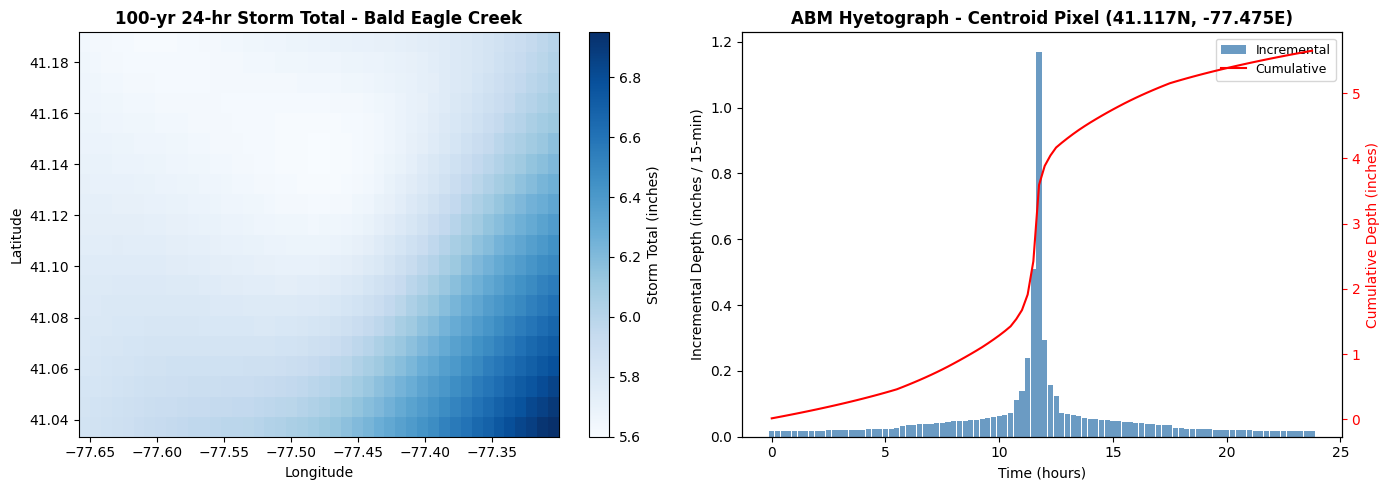

In [10]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

ds2 = xr.open_dataset(nc_path_proj, decode_timedelta=False)
lats2 = ds2.lat.values
lons2 = ds2.lon.values
totals2 = ds2['precip_cumulative'].values[-1, :, :]
incr2   = ds2['precip_incremental'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spatial total
ax = axes[0]
im = ax.imshow(
    totals2,
    origin='lower',
    extent=[lons2.min(), lons2.max(), lats2.min(), lats2.max()],
    cmap='Blues',
    aspect='auto',
)
plt.colorbar(im, ax=ax, label='Storm Total (inches)')
ax.set_title('100-yr 24-hr Storm Total - Bald Eagle Creek', fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

print(f"Grid dimensions: {len(lats2)} lat x {len(lons2)} lon")
print(f"Storm total range: {np.nanmin(totals2):.3f} - {np.nanmax(totals2):.3f} inches")

# Centroid pixel hyetograph
li = len(lats2) // 2
lj = len(lons2) // 2
px_incr  = incr2[:, li, lj]
px_cumul = ds2['precip_cumulative'].values[:, li, lj]
time_hr2 = np.arange(len(px_incr)) * 15 / 60.0

ax2 = axes[1]
ax2.bar(time_hr2, px_incr, width=15/60*0.9, color='steelblue', alpha=0.8, label='Incremental')
ax2b = ax2.twinx()
ax2b.plot(time_hr2, px_cumul, 'r-', linewidth=1.5, label='Cumulative')
ax2b.set_ylabel('Cumulative Depth (inches)', color='r')
ax2b.tick_params(axis='y', colors='r')
ax2.set_xlabel('Time (hours)')
ax2.set_ylabel('Incremental Depth (inches / 15-min)')
ax2.set_title(f'ABM Hyetograph - Centroid Pixel ({lats2[li]:.3f}N, {lons2[lj]:.3f}E)', fontweight='bold')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.show()
ds2.close()

## 4. Vary Peak Position

The `peak_position_percent` parameter controls where the largest block is placed.
Common engineering choices:

| Position | Typical use |
|---|---|
| 25% | Early-peaking storm |
| 50% | Centered (default) |
| 67% | Late-peaking (common for design storms) |

Compare hyetographs at three peak positions for the centroid pixel.

2026-06-12 14:45:26 - ras_commander.precip.AbmHyetographGrid - INFO - Generating ABM grid: ARI=100yr, duration=24.0hr, dt=15min, peak@25.0%, bounds=(-95.5, 29.5, -95.0, 30.0)


2026-06-12 14:45:26 - ras_commander.precip.AbmHyetographGrid - INFO - Downloading Atlas 14 data for 7 hourly durations...


2026-06-12 14:45:26 - ras_commander.precip.Atlas14Grid - INFO - Extracting Atlas 14 data for bounds (-95.5250, 29.4750, -94.9750, 30.0250): lat[658:724], lon[3538:3604]


2026-06-12 14:48:45 - ras_commander.precip.Atlas14Grid - INFO - Data transfer: 536.0 KB (vs 2655.6 MB full grid, 100.0% reduction)


2026-06-12 14:48:45 - ras_commander.precip.AbmHyetographGrid - INFO - Using ARI index 5 → 100-year return period


...

2026-06-12 14:55:20 - ras_commander.precip.StormGenerator - INFO - Downloading Atlas 14 data for (29.75, -95.25)...


2026-06-12 14:55:21 - ras_commander.precip.StormGenerator - INFO - Downloaded Atlas 14 data for region: Texas


2026-06-12 14:55:21 - ras_commander.precip.AbmHyetographGrid - INFO - Computing ABM temporal distribution across grid (96 intervals)...


2026-06-12 14:55:21 - ras_commander.precip.AbmHyetographGrid - INFO - Wrote NetCDF: <workspace>\examples\abm_peak67pct.nc (96 timesteps × 66 lat × 66 lon)


2026-06-12 14:55:21 - ras_commander.precip.AbmHyetographGrid - INFO - ABM grid complete → <workspace>\examples\abm_peak67pct.nc


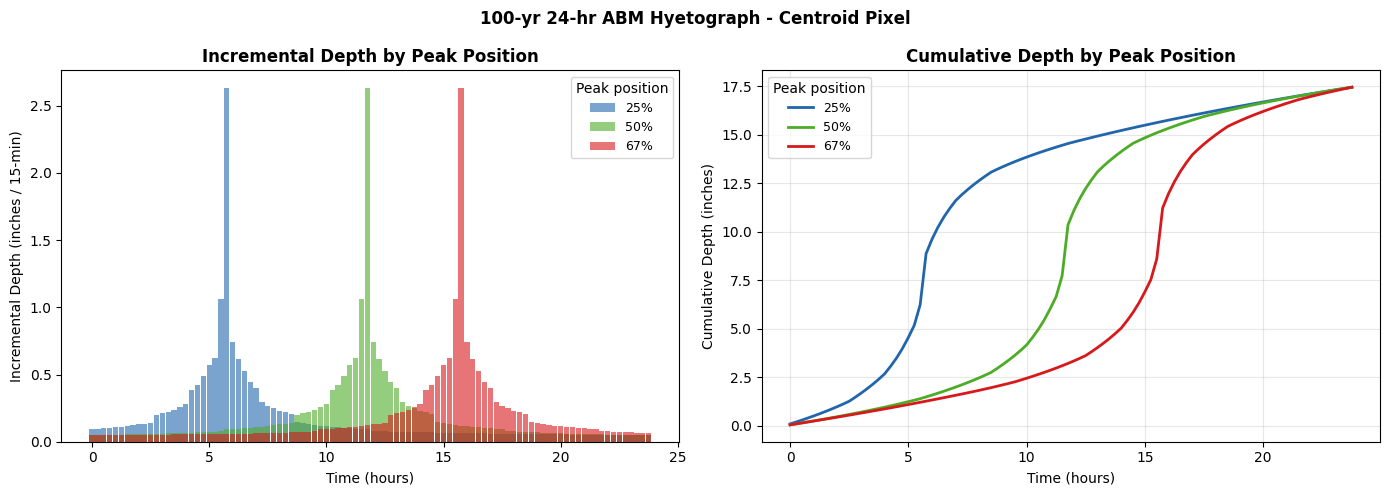

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

peak_positions = [25.0, 50.0, 67.0]
colors = ['#2166ac', '#4dac26', '#d7191c']
results_by_peak = {}

for peak_pct in peak_positions:
    out = AbmHyetographGrid.generate(
        bounds=BOUNDS,
        ari_years=ARI_YEARS,
        storm_duration_hours=STORM_DURATION_HR,
        timestep_minutes=TIMESTEP_MIN,
        peak_position_percent=peak_pct,
        output_netcdf=f"abm_peak{int(peak_pct)}pct.nc",
    )
    ds_tmp = xr.open_dataset(out, decode_timedelta=False)
    li = ds_tmp.lat.shape[0] // 2
    lj = ds_tmp.lon.shape[0] // 2
    results_by_peak[peak_pct] = {
        'incr':  ds_tmp['precip_incremental'].values[:, li, lj],
        'cumul': ds_tmp['precip_cumulative'].values[:, li, lj],
    }
    ds_tmp.close()

time_hr = np.arange(int(STORM_DURATION_HR * 60 / TIMESTEP_MIN)) * TIMESTEP_MIN / 60.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax_incr, ax_cumul = axes
for (peak_pct, data), color in zip(results_by_peak.items(), colors):
    ax_incr.bar(time_hr, data['incr'], width=TIMESTEP_MIN/60*0.9,
                color=color, alpha=0.6, label=f'{peak_pct:.0f}%')
    ax_cumul.plot(time_hr, data['cumul'], color=color, linewidth=2,
                  label=f'{peak_pct:.0f}%')

ax_incr.set_xlabel('Time (hours)')
ax_incr.set_ylabel('Incremental Depth (inches / 15-min)')
ax_incr.set_title('Incremental Depth by Peak Position', fontweight='bold')
ax_incr.legend(title='Peak position', fontsize=9)

ax_cumul.set_xlabel('Time (hours)')
ax_cumul.set_ylabel('Cumulative Depth (inches)')
ax_cumul.set_title('Cumulative Depth by Peak Position', fontweight='bold')
ax_cumul.legend(title='Peak position', fontsize=9)
ax_cumul.grid(True, alpha=0.3)

plt.suptitle(f'{ARI_YEARS}-yr {STORM_DURATION_HR:.0f}-hr ABM Hyetograph - Centroid Pixel',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Alternative: generate_from_asc_files()

If you have already downloaded NOAA Atlas 14 ESRI ASCII raster (.asc) files from the
[NOAA Precipitation Frequency Data Server](https://hdsc.nws.noaa.gov/pfds/pfds_gis.html),
use `generate_from_asc_files()` instead. This is useful when:

- You need sub-hourly depth grids (5-min, 10-min, 15-min, 30-min) at full spatial resolution
  rather than centroid DDF ratios
- You want full control over the input depth grids (e.g., manually adjusted values)
- You are working offline or from a cached copy of Atlas 14 data

**How to get .asc files from NOAA:**
1. Go to https://hdsc.nws.noaa.gov/pfds/pfds_gis.html
2. Select your state and return period
3. Download the ESRI ASCII grid for each required duration

Raw values in NOAA .asc files are in **hundredths of inches** — `scale_factor=0.01` (default)
converts them to inches.

In [12]:
# Example: generate_from_asc_files() API
# (Requires pre-downloaded .asc files — comment out if files not available)

# from pathlib import Path
# from ras_commander.precip import AbmHyetographGrid
#
# asc_dir = Path("atlas14_asc_files")  # folder containing downloaded .asc files
#
# asc_files = {
#     5/60:  asc_dir / "tx100yr05m.asc",   # 5-min
#     10/60: asc_dir / "tx100yr10m.asc",   # 10-min
#     15/60: asc_dir / "tx100yr15m.asc",   # 15-min
#     30/60: asc_dir / "tx100yr30m.asc",   # 30-min
#     1.0:   asc_dir / "tx100yr01h.asc",   # 1-hr
#     2.0:   asc_dir / "tx100yr02h.asc",   # 2-hr
#     3.0:   asc_dir / "tx100yr03h.asc",   # 3-hr
#     6.0:   asc_dir / "tx100yr06h.asc",   # 6-hr
#     12.0:  asc_dir / "tx100yr12h.asc",   # 12-hr
#     24.0:  asc_dir / "tx100yr24h.asc",   # 24-hr
# }
#
# nc_path_asc = AbmHyetographGrid.generate_from_asc_files(
#     asc_files=asc_files,
#     ari_years=100,
#     storm_duration_hours=24.0,
#     timestep_minutes=15,
#     peak_position_percent=50.0,
#     output_netcdf="abm_100yr_24hr_from_asc.nc",
#     scale_factor=0.01,  # NOAA .asc files are in hundredths of inches
# )
# print(f"Output: {nc_path_asc}")

print("generate_from_asc_files() example is commented out.")
print("Download .asc files from https://hdsc.nws.noaa.gov/pfds/pfds_gis.html and update paths above.")

generate_from_asc_files() example is commented out.
Download .asc files from https://hdsc.nws.noaa.gov/pfds/pfds_gis.html and update paths above.


## 6. Cleanup

In [13]:
import os

# Remove generated NetCDF files
for f in [
    "abm_houston_100yr_24hr.nc",
    "abm_peak25pct.nc",
    "abm_peak50pct.nc",
    "abm_peak67pct.nc",
]:
    p = Path(f)
    if p.exists():
        p.unlink()
        print(f"Removed {f}")

# Optionally remove extracted example project
# import shutil
# shutil.rmtree(project_path.parent, ignore_errors=True)
print("Done.")

Removed abm_houston_100yr_24hr.nc
Removed abm_peak25pct.nc
Removed abm_peak50pct.nc
Removed abm_peak67pct.nc
Done.


## Summary

This notebook demonstrated two end-to-end workflows for generating gridded ABM hyetographs:

**Example 1 — Direct Bounds (`generate`):**
- Provide a bounding box, ARI, duration, timestep, and peak position
- Atlas 14 spatial depth data is fetched automatically via HTTP byte-range
- Sub-hourly intervals are filled via centroid DDF ratios
- Output: CF-1.8 NetCDF with `precip_incremental` and `precip_cumulative`

**Example 2 — HEC-RAS Project Bounds:**
- Use `Atlas14Grid.get_pfe_from_project()` to read the 2D flow area extent
- Pass the returned `bounds` tuple directly to `AbmHyetographGrid.generate()`
- Grid is automatically sized to the model domain

**Key Parameters:**
- `ari_years` — return period: 2, 5, 10, 25, 50, 100, 200, 500, 1000
- `storm_duration_hours` — total storm duration (>= 1 hr for auto-download mode)
- `timestep_minutes` — must evenly divide storm duration
- `peak_position_percent` — 0–100; 50% = centered, 67% = late-peaking

**Alternative Workflow (`generate_from_asc_files`):**
- For full sub-hourly spatial resolution, supply pre-downloaded NOAA .asc grids
- Useful for offline workflows or when exact spatial sub-hourly data is required

**References:**
- Chow, V.T., Maidment, D.R., Mays, L.W. (1988). *Applied Hydrology*. McGraw-Hill.
- [NOAA Atlas 14](https://hdsc.nws.noaa.gov/pfds/)
- [NOAA GIS Data Downloads](https://hdsc.nws.noaa.gov/pfds/pfds_gis.html)